In [18]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [19]:
#random data set for classification
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [20]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.793311,-2.039649,3.267043,0.172242,0.662870,1
1,-0.491977,2.179933,2.099301,-0.895838,1.964222,1
2,-0.830128,2.695434,-1.452714,-2.778198,2.923273,1
3,0.829876,1.166662,-1.044510,1.772765,-0.682777,0
4,0.411807,2.900001,-1.476350,1.677090,-1.155696,0


In [21]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [25]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df

In [26]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [27]:
df1 = combined_sampling(df,0.5,0.5)

In [28]:
df2 = combined_sampling(df,0.5,0.5)

In [29]:
df3 = combined_sampling(df,0.5,0.5)

In [30]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='object')
Index(['col1', 'col3', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')


In [141]:
df3

,col3,col2,target
2,-0.943985,-1.727474,1
53,2.879522,-1.179645,0
17,-0.601854,0.240279,1
12,-1.209724,0.077615,1
8,-0.147061,-0.352877,0
6,-1.029536,-0.770751,1
94,-0.930578,-1.265605,1
4,0.022074,-0.911493,0
38,2.538559,-1.042250,0
40,0.595038,-0.162759,0


In [31]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [32]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [33]:
from sklearn.tree import plot_tree

[Text(0.6, 0.9285714285714286, 'x[1] <= 0.553\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.3333333333333333, 0.7857142857142857, 'x[0] <= 1.196\ngini = 0.337\nsamples = 28\nvalue = [22, 6]'),
 Text(0.4666666666666667, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'x[0] <= 0.228\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.06666666666666667, 0.5, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.2, 0.5, 'x[0] <= 0.834\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.13333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.26666666666666666, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5333333333333333, 0.6428571428571429, 'x[1] <= -0.532\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.4666666666666667, 0.5, 'x[0] <= 1.889\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.53333333

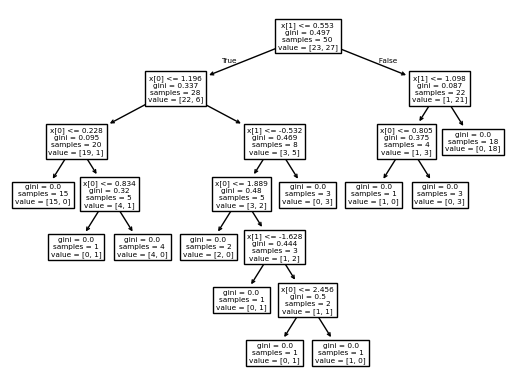

In [34]:
plot_tree(clf1)

[Text(0.5, 0.9, 'x[0] <= 0.118\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.2, 0.7, 'x[0] <= -0.728\ngini = 0.077\nsamples = 25\nvalue = [1, 24]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.3, 0.5, 'x[0] <= -0.558\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.8, 0.7, 'x[1] <= 1.571\ngini = 0.211\nsamples = 25\nvalue = [22, 3]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'x[0] <= 1.253\ngini = 0.153\nsamples = 24\nvalue = [22, 2]'),
 Text(0.6, 0.3, 'x[0] <= 1.131\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.3, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.9, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

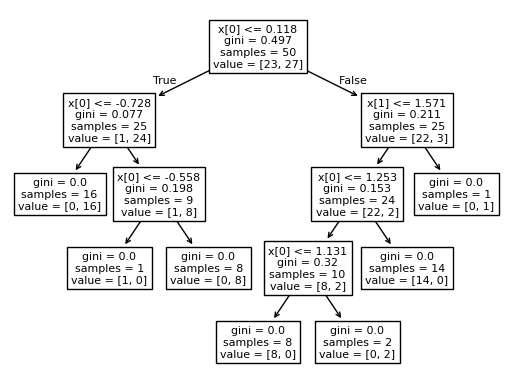

In [35]:
plot_tree(clf2)

In [ ]:
plot_tree(clf3)

In [40]:
#clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
x = [-1.042498, -0.064323]
clf1.predict(pd.DataFrame([x], columns=clf1.feature_names_in_))

array([0])

In [42]:
#clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
x = [-1.042498, -0.064323]
clf2.predict(pd.DataFrame([x], columns=clf2.feature_names_in_))

array([1])

In [43]:
#clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
x = [-1.042498, -0.064323]
clf3.predict(pd.DataFrame([x], columns=clf3.feature_names_in_))

array([1])

In [44]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
36,2.279104,-4.258013,-1.579698,2.024170,3.068762,0
93,2.202670,-1.746134,-2.603319,1.133420,1.324936,0
25,-2.791089,0.673409,2.846963,-0.549764,0.640549,1
18,1.427421,-1.531012,-0.797643,1.484581,1.070083,0
50,1.191724,-0.906518,-0.699991,1.009563,-1.076473,1
44,-1.482069,0.541105,2.987850,-0.287098,1.201221,1
64,-2.864544,-0.979895,2.153221,-0.796368,-0.594555,1
65,0.937023,-2.618034,-1.066067,0.060385,2.637690,0
35,-2.162711,0.484304,1.167944,-3.320847,0.776620,1
89,-2.708185,3.665082,1.555800,-1.106140,5.472970,1
